# Chart: SVD vs. PCA Low Rank Approximations


[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week13/chart_svd_vs_pca_low_rank_approximations.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week13/chart_svd_vs_pca_low_rank_approximations.ipynb)



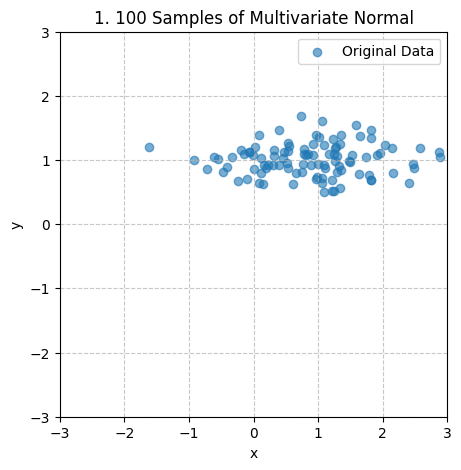

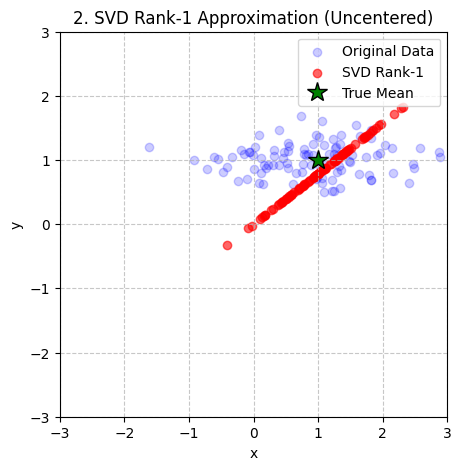

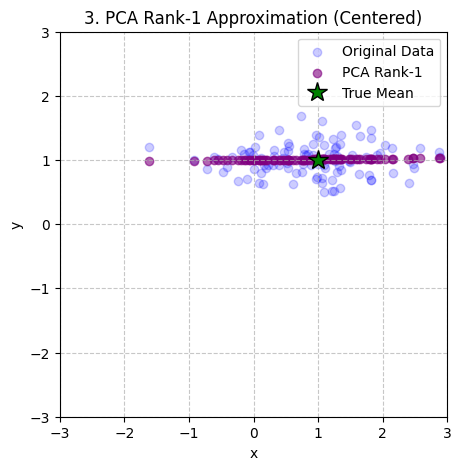

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

[xmin, xmax] = [-3, 3]
[ymin, ymax] = [-3, 3]

# 1. Set parameters and generate 100 samples
mean = [1, 1]
cov = [[1**2, 0], [0, 0.25**2]]
np.random.seed(42)
data = np.random.multivariate_normal(mean, cov, 100)

# 2. Compute SVD rank-1 approximation (Uncentered)
U, S, Vt = np.linalg.svd(data, full_matrices=False)
rank_1_svd = U[:, :1] @ np.diag(S[:1]) @ Vt[:1, :]

# 3. Compute PCA rank-1 approximation (Centered)
data_mean = np.mean(data, axis=0)
centered_data = data - data_mean
Uc, Sc, Vtc = np.linalg.svd(centered_data, full_matrices=False)
rank_1_pca = (Uc[:, :1] @ np.diag(Sc[:1]) @ Vtc[:1, :]) + data_mean

# 4. Plotting

# Plot 1: Original Data Only
plt.figure(figsize=(5, 5))
plt.scatter(data[:, 0], data[:, 1], alpha=0.6, label='Original Data')
plt.title("1. 100 Samples of Multivariate Normal")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plot 2: SVD (Uncentered)
plt.figure(figsize=(5, 5))
plt.scatter(data[:, 0], data[:, 1], alpha=0.2, color='blue', label='Original Data')
plt.scatter(rank_1_svd[:, 0], rank_1_svd[:, 1], color='red', alpha=0.6, label='SVD Rank-1')
plt.plot(mean[0], mean[1], 'g*', markersize=15, label='True Mean', markeredgecolor='black')
plt.title("2. SVD Rank-1 Approximation (Uncentered)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plot 3: PCA (Centered)
plt.figure(figsize=(5, 5))
plt.scatter(data[:, 0], data[:, 1], alpha=0.2, color='blue', label='Original Data')
plt.scatter(rank_1_pca[:, 0], rank_1_pca[:, 1], color='purple', alpha=0.6, label='PCA Rank-1')
plt.plot(mean[0], mean[1], 'g*', markersize=15, label='True Mean', markeredgecolor='black')
plt.title("3. PCA Rank-1 Approximation (Centered)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()